
# Pokec Network Study (sampled version)

Notebook reconstruit depuis le PDF fourni. Objectifs :
1) Charger un sous-graphe connecté (~10k nœuds) du réseau d’amitié Pokec  
2) Nettoyer/encoder des attributs utilisateurs  
3) Attacher les features au graphe et sauvegarder  
4) AEG: propriétés globales, centralités, communautés  
5) Expériences GNN: GCN / GraphSAGE / GAT pour prédire la centralité  
6) Visualisations d'embeddings, link prediction, comparaison Louvain vs embeddings

> Remarque: Le code est reproduit au mieux depuis le document; quelques ruptures de lignes ou caractères spéciaux peuvent nécessiter un léger nettoyage si vous l’exécutez.


## 1.1 Load a partial graph and sample a connected subgraph

In [1]:

# ==================================
# Imports
# ==================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import os

# Optional: style (may warn on newer matplotlib)
try:
    plt.style.use("seaborn-v0_8")
except Exception:
    pass


In [2]:

import os
import networkx as nx
import random
import numpy as np
import pickle

# Fixer la graine pour reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

GRAPH_PATH = "dataset/pokec_subgraph_relationships.gpickle"
SOURCE_PATH = "dataset/soc-pokec-relationships.txt"

# --- Chargement partiel du graphe brut ---
def load_partial_graph(path, max_edges=500_000):
    G = nx.Graph()
    with open(path) as f:
        for i, line in enumerate(f):
            if i >= max_edges:
                break
            try:
                u, v = map(int, line.strip().split('\t'))
                G.add_edge(u, v)
            except Exception:
                continue
    return G

# --- Sauvegarde / Chargement compatible NetworkX 3.x ---
def save_graph_gpickle(G, path):
    with open(path, "wb") as f:
        pickle.dump(G, f)

def load_graph_gpickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# --- Multi-Seed BFS Sampling ---
def multi_seed_bfs(G, num_seeds=15, depth_limit=3, target_nodes=10_000):
    """Combine plusieurs petits BFS pour un sous-graphe plus diversifié."""
    seeds = random.sample(list(G.nodes()), min(num_seeds, max(1, len(G))))
    all_nodes = set()
    for s in seeds:
        nodes = nx.bfs_tree(G, s, depth_limit=depth_limit).nodes()
        all_nodes.update(nodes)
        if len(all_nodes) >= target_nodes:
            break
    H = G.subgraph(all_nodes).copy()
    # Si le graphe est trop petit, on élargit la profondeur
    if H.number_of_nodes() < target_nodes * 0.8 and depth_limit < 10:
        print(f"Too small ({H.number_of_nodes()} nodes), increasing depth...")
        return multi_seed_bfs(G, num_seeds, depth_limit + 1, target_nodes)
    return H

# --- Vérifie si le graphe est déjà sauvegardé ---
if os.path.exists(GRAPH_PATH):
    print(f"Loading saved subgraph from {GRAPH_PATH}...")
    H = load_graph_gpickle(GRAPH_PATH)
    print(f"Loaded saved graph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
else:
    print("Loading part of Pokec edges...")
    G = load_partial_graph(SOURCE_PATH, max_edges=500_000)
    print(f"Partial graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print("Sampling with multiple BFS seeds for better structure...")
    H = multi_seed_bfs(G, num_seeds=15, depth_limit=3, target_nodes=10_000)
    print(f"Sampled subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
    os.makedirs(os.path.dirname(GRAPH_PATH), exist_ok=True)
    save_graph_gpickle(H, GRAPH_PATH)
    print(f"Saved subgraph to {GRAPH_PATH}")

density = nx.density(H)
clustering = nx.average_clustering(H)
print("density:", density, "clustering:", clustering)


Loading saved subgraph from dataset/pokec_subgraph_relationships.gpickle...
Loaded saved graph: 10681 nodes, 23726 edges
density: 0.0004159789496347429 clustering: 0.06112487792880805


## 1.2–1.3 Pré-traitement des données utilisateurs

In [3]:

import pandas as pd
import numpy as np
import networkx as nx
import os

PROFILES_RAW = "dataset/soc-pokec-profiles.txt"
GRAPH_PREP_PATH = "dataset/pokec_graph_preprocessed.gpickle"
FEATURES_PREP_PATH = "dataset/pokec_features_preprocessed.parquet"

print("Préparation complète à partir du fichier brut Pokec...")

# Étape 1 : Lecture + nettoyage
profiles = pd.read_csv(PROFILES_RAW, sep="\t", header=None, low_memory=False)
cols = ["user_id","public","completion","gender","region","last_login","registration",
        "age","body","work_field","languages","hobbies","interests","music","movies",
        "religion","cars","politics","looking_for","smoker","drinker"]
profiles.columns = cols + list(range(len(cols), profiles.shape[1]))

df = profiles[["user_id","gender","age","region","smoker","drinker","completion"]].copy()
df = df.dropna(subset=["user_id"])
df["user_id"] = df["user_id"].astype(int)

df["gender"] = df["gender"].map({1.0:"male", 0.0:"female"}).fillna("unknown")
df["region"] = df["region"].astype(str).str.split(",").str[0]
df["age"] = pd.to_numeric(df["age"], errors="coerce").replace(0, np.nan)

def simplify_text(val):
    if not isinstance(val, str):
        return "unknown"
    val = val.lower()
    # crude Slovak keywords from PDF
    if any(k in val for k in ["ne", "nie", "vobec"]):
        return "no"
    if any(k in val for k in ["ano", "áno", "hej", "pijem", "obcas", "občas"]):
        return "yes"
    return "unknown"

df["smoker_clean"] = df["smoker"].apply(simplify_text)
df["drinker_clean"] = df["drinker"].apply(simplify_text)

# Étape 2 : Nettoyage structurel du graphe
H.remove_edges_from(nx.selfloop_edges(H))
H = nx.Graph(H)
isolates = list(nx.isolates(H))
if isolates:
    H.remove_nodes_from(isolates)
print(f"Graphe nettoyé : {H.number_of_nodes()} nœuds, {H.number_of_edges()} arêtes.")


Préparation complète à partir du fichier brut Pokec...
Graphe nettoyé : 10681 nœuds, 23726 arêtes.


In [4]:

# Étape 3 : Encodage + standardisation
from sklearn.preprocessing import LabelEncoder

df["user_id"] = df["user_id"].astype(int)
H_nodes = pd.Index([int(n) for n in H.nodes()])

feat = df.set_index("user_id").reindex(H_nodes)
feat = feat.reset_index().rename(columns={"index": "user_id"})
print(f"After reindex: {feat.shape[0]} rows (should equal {H.number_of_nodes()} nodes)")

for col in ["age", "completion"]:
    feat[col] = pd.to_numeric(feat[col], errors="coerce")
    feat[col] = feat[col].fillna(feat[col].mean())

feat["age_z"] = (feat["age"] - feat["age"].mean()) / (feat["age"].std() + 1e-8)
feat["completion_z"] = (feat["completion"] - feat["completion"].mean()) / (feat["completion"].std() + 1e-8)

region_counts = feat["region"].value_counts(dropna=True)
rare_regions = region_counts[region_counts < 50].index
feat["region"] = feat["region"].replace(rare_regions, "autre").fillna("autre")

for col in ["gender", "region", "smoker_clean", "drinker_clean"]:
    feat[col] = feat[col].fillna("unknown")

for col in ["gender", "region", "smoker_clean", "drinker_clean"]:
    le = LabelEncoder()
    feat[col] = le.fit_transform(feat[col].astype(str))

feat_encoded = feat[["gender", "region", "smoker_clean", "drinker_clean", "age_z", "completion_z"]]
X = feat_encoded.fillna(0).astype("float32")

feat_attrs = feat.set_index("user_id").to_dict("index")
nx.set_node_attributes(H, feat_attrs)

print(f"OK: X = {X.shape}, graph has {H.number_of_nodes()} nodes")


After reindex: 10681 rows (should equal 10681 nodes)
OK: X = (10681, 6), graph has 10681 nodes


In [5]:

# Étape 4 : Sauvegarde
os.makedirs("dataset", exist_ok=True)

import pickle
with open(GRAPH_PREP_PATH, "wb") as f:
    pickle.dump(H, f)

X.to_parquet(FEATURES_PREP_PATH)
print(f"Graphe sauvegardé → {GRAPH_PREP_PATH}")
print(f"Features sauvegardées → {FEATURES_PREP_PATH}")


Graphe sauvegardé → dataset/pokec_graph_preprocessed.gpickle
Features sauvegardées → dataset/pokec_features_preprocessed.parquet


## 1.4 Visualisation locale (color by region)

Visualizing connected subgraph: 6890 nodes, 7168 edges


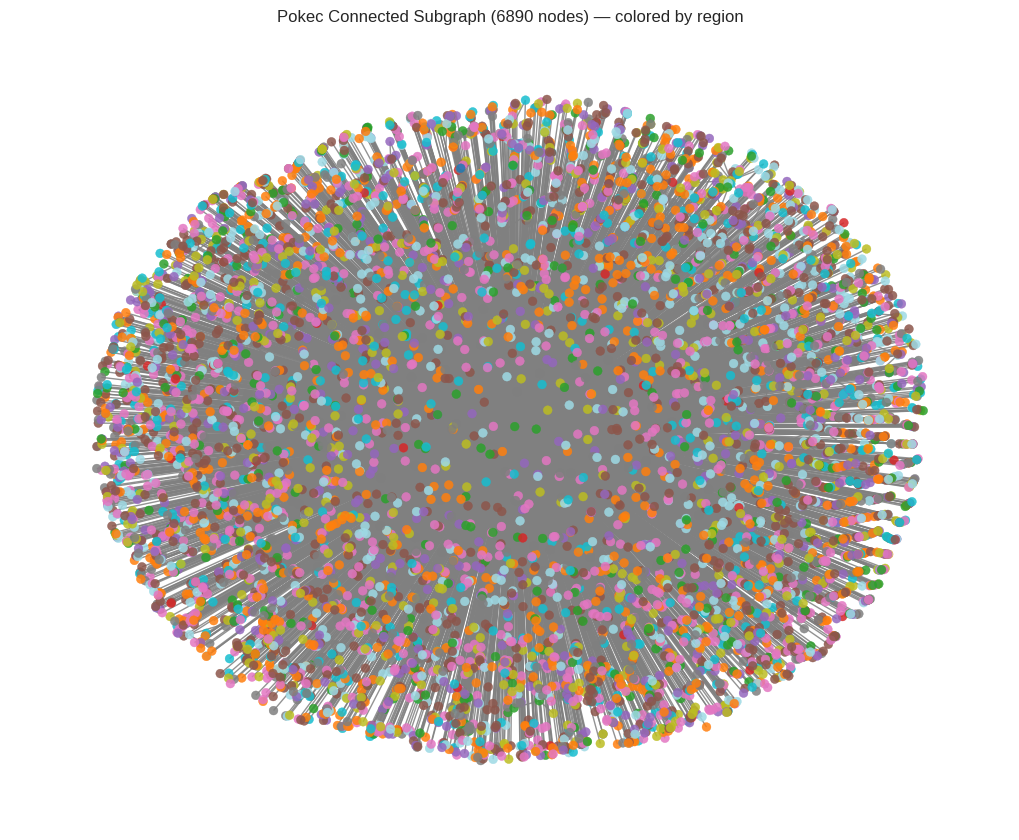

In [6]:

import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

start = random.choice(list(H.nodes()))
connected_nodes = list(nx.single_source_shortest_path_length(H, start, cutoff=2).keys())
S = H.subgraph(connected_nodes).copy()
print(f"Visualizing connected subgraph: {S.number_of_nodes()} nodes, {S.number_of_edges()} edges")

pos = nx.spring_layout(S, seed=42, iterations=30)

regions = [S.nodes[n].get("region", "unknown") for n in S.nodes()]
unique_regions = sorted(set(regions))
colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(unique_regions))))
color_dict = {r: colors[i % 20] for i, r in enumerate(unique_regions)}
node_colors = [color_dict[S.nodes[n].get("region", "unknown")] for n in S.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(S, pos, node_color=node_colors, node_size=40, edge_color="gray", with_labels=False, alpha=0.85)
plt.title(f"Pokec Connected Subgraph ({S.number_of_nodes()} nodes) — colored by region")
plt.show()


## 2. Analyse Exploratoire du Graphe (AEG)

In [7]:

import pickle
import networkx as nx
import pandas as pd

with open("dataset/pokec_graph_preprocessed.gpickle", "rb") as f:
    H = pickle.load(f)
X = pd.read_parquet("dataset/pokec_features_preprocessed.parquet")

print(f"Graphe chargé : {H.number_of_nodes()} nœuds, {H.number_of_edges()} arêtes")
print(f"Matrice de features : {X.shape[0]} lignes, {X.shape[1]} colonnes")


Graphe chargé : 10681 nœuds, 23726 arêtes
Matrice de features : 10681 lignes, 6 colonnes


In [8]:

# Propriétés globales
import numpy as np
import random
import networkx as nx

N = H.number_of_nodes()
M = H.number_of_edges()
density = nx.density(H)
clustering = nx.transitivity(H)

largest_cc = max(nx.connected_components(H), key=len)
H_cc = H.subgraph(largest_cc).copy()

sample_size = min(2000, len(H_cc))
sample_nodes = random.sample(list(H_cc.nodes()), sample_size)

distances = []
for n in sample_nodes:
    sp_lengths = nx.single_source_shortest_path_length(H_cc, n)
    distances.extend(sp_lengths.values())

avg_path_length = np.mean(distances)
diameter_approx = np.percentile(distances, 99.9)

print(f"Nombre de nœuds : {N}")
print(f"Nombre d’arêtes : {M}")
print(f"Densité : {density:.6f}")
print(f"Clustering global : {clustering:.4f}")
print(f"Longueur moyenne approximée du plus court chemin : {avg_path_length:.3f}")
print(f"Diamètre approximé (99.9e percentile) : {diameter_approx:.0f}")


Nombre de nœuds : 10681
Nombre d’arêtes : 23726
Densité : 0.000416
Clustering global : 0.0016
Longueur moyenne approximée du plus court chemin : 2.976
Diamètre approximé (99.9e percentile) : 6


## 3. Étude de la Centralité du Graphe

In [9]:

# Centralité de degré
degree_centrality = nx.degree_centrality(H_cc)
print(f"Centralité de degré calculée pour {len(degree_centrality)} nœuds.")
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_degree:
    print(f"Node {node}: degree = {score:.4f}")


Centralité de degré calculée pour 10681 nœuds.
Node 5935: degree = 0.6450
Node 7429: degree = 0.0924
Node 2230: degree = 0.0846
Node 224: degree = 0.0244
Node 189: degree = 0.0234


In [10]:

# Betweenness (approx)
betweenness_centrality = nx.betweenness_centrality(H_cc, k=1000, seed=42)
print("Centralité d’intermédiarité calculée (approx).")
top_betw = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_betw:
    print(f"Node {node}: betweenness = {score:.4f}")


Centralité d’intermédiarité calculée (approx).
Node 5935: betweenness = 0.8624
Node 2230: betweenness = 0.1391
Node 7429: betweenness = 0.1327
Node 7438: betweenness = 0.0562
Node 224: betweenness = 0.0481


In [11]:

# Closeness
closeness_centrality = nx.closeness_centrality(H_cc)
print(f"Centralité de proximité calculée pour {len(closeness_centrality)} nœuds.")
top_close = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_close:
    print(f"Node {node}: closeness = {score:.4f}")


Centralité de proximité calculée pour 10681 nœuds.
Node 5935: closeness = 0.6146
Node 7438: closeness = 0.4827
Node 224: closeness = 0.4669
Node 39244: closeness = 0.4596
Node 9370: closeness = 0.4503


In [12]:

# PageRank
pagerank = nx.pagerank(H_cc, alpha=0.85)
print(f"PageRank calculé pour {len(pagerank)} nœuds.")
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_pr:
    print(f"Node {node}: PageRank = {score:.4f}")


PageRank calculé pour 10681 nœuds.
Node 5935: PageRank = 0.2573
Node 2230: PageRank = 0.0324
Node 7429: PageRank = 0.0167
Node 189: PageRank = 0.0066
Node 7607: PageRank = 0.0035


In [13]:

# Eigenvector centrality
try:
    eigen_centrality = nx.eigenvector_centrality_numpy(H_cc)
except nx.NetworkXError:
    eigen_centrality = nx.eigenvector_centrality(H_cc, max_iter=500)

print(f"Centralité de vecteur propre calculée pour {len(eigen_centrality)} nœuds.")
top_eig = sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_eig:
    print(f"Node {node}: eigenvector = {score:.4f}")


Centralité de vecteur propre calculée pour 10681 nœuds.
Node 5935: eigenvector = 0.7065
Node 189: eigenvector = 0.0200
Node 224: eigenvector = 0.0108
Node 76: eigenvector = 0.0105
Node 8514: eigenvector = 0.0099


In [14]:

# Fusion centralités + attributs
import pandas as pd

centralities_df = pd.DataFrame({
    "node": list(H_cc.nodes()),
    "degree": [degree_centrality[n] for n in H_cc.nodes()],
    "betweenness": [betweenness_centrality[n] for n in H_cc.nodes()],
    "closeness": [closeness_centrality[n] for n in H_cc.nodes()],
    "pagerank": [pagerank[n] for n in H_cc.nodes()],
    "eigenvector": [eigen_centrality[n] for n in H_cc.nodes()],
})

attrs = pd.DataFrame.from_dict(dict(H_cc.nodes(data=True)), orient="index").reset_index()
attrs.rename(columns={"index": "node"}, inplace=True)

merged = pd.merge(centralities_df, attrs, on="node", how="inner")
print(f"Merged dataset: {merged.shape[0]} nodes, {merged.shape[1]} columns")
merged.head()


Merged dataset: 10681 nodes, 16 columns


,node,degree,betweenness,closeness,pagerank,eigenvector,gender,age,region,smoker,drinker,completion,smoker_clean,drinker_clean,age_z,completion_z
0,131073,0.000094,0.000000,0.380681,0.000045,0.008503,0,17.000000,10,NaN,NaN,17,1,1,-6.579401e-01,-1.576050
1,32771,0.000094,0.000000,0.380681,0.000045,0.008503,1,20.140809,7,NaN,NaN,17,1,1,7.442262e-16,-1.576050
2,229381,0.000094,0.000000,0.380681,0.000045,0.008503,0,20.140809,9,zakladne,"modra, fialova",78,0,1,7.442262e-16,0.998208
3,229382,0.000094,0.000000,0.380681,0.000045,0.008503,1,20.000000,6,██ ██ ██ ██,██ ██ ██ ██,86,1,1,-2.949689e-02,1.335815
4,7,0.001685,0.000735,0.329477,0.000174,0.000392,0,22.000000,10,NaN,NaN,12,1,1,3.894652e-01,-1.787054


In [15]:

# Nouvelle cible: y = log1p(degree) standardisé
nodes = list(H_cc.nodes())
deg_brut = pd.Series(dict(H_cc.degree()))
y_raw = np.log1p(deg_brut.reindex(nodes).fillna(0).astype(float))
y_mean, y_std = y_raw.mean(), y_raw.std()
y_stdzd = (y_raw - y_mean) / (y_std + 1e-8)

target_df = pd.DataFrame({"node": nodes, "y": y_stdzd.values})
target_df.head()


,node,y
0,131073,-0.482436
1,32771,-0.482436
2,229381,-0.482436
3,229382,-0.482436
4,7,2.568486


In [16]:

# Corrélations de Pearson
from scipy.stats import pearsonr

num_cols = ["age", "completion"]
centrality_cols = ["degree", "betweenness", "closeness", "pagerank", "eigenvector"]

for y in centrality_cols:
    print(f"\n=== Corrélations avec {y} ===")
    for x in num_cols:
        valid = merged[[x, y]].dropna()
        if len(valid) > 2:
            r, p = pearsonr(valid[x], valid[y])
            print(f"{x:15s} r={r:.3f} p={p:.4g}")



=== Corrélations avec degree ===
age             r=0.006 p=0.543
completion      r=-0.014 p=0.1397

=== Corrélations avec betweenness ===
age             r=0.003 p=0.7185
completion      r=-0.014 p=0.156

=== Corrélations avec closeness ===
age             r=-0.230 p=8.844e-129
completion      r=0.070 p=4.144e-13

=== Corrélations avec pagerank ===
age             r=0.002 p=0.8376
completion      r=-0.015 p=0.1155

=== Corrélations avec eigenvector ===
age             r=-0.121 p=4.1e-36
completion      r=0.017 p=0.07929


In [17]:

# Comparaisons catégorielles
cat_cols = ["gender", "region", "smoker_clean", "drinker_clean"]
for cat in cat_cols:
    if cat in merged.columns:
        print(f"\n===== {cat.upper()} =====")
        print(merged.groupby(cat)[["degree","betweenness","closeness","pagerank","eigenvector"]]
              .mean().round(3).sort_values("pagerank", ascending=False))



===== GENDER =====
        degree  betweenness  closeness  pagerank  eigenvector
gender                                                       
0        0.000          0.0      0.340       0.0        0.005
1        0.001          0.0      0.352       0.0        0.006
2        0.000          0.0      0.381       0.0        0.009

===== REGION =====
        degree  betweenness  closeness  pagerank  eigenvector
region                                                       
2        0.001        0.002      0.355     0.001        0.008
0        0.000        0.000      0.381     0.000        0.009
1        0.001        0.000      0.312     0.000        0.003
3        0.000        0.001      0.332     0.000        0.005
4        0.000        0.000      0.364     0.000        0.007
5        0.000        0.000      0.371     0.000        0.008
6        0.000        0.000      0.371     0.000        0.008
7        0.000        0.000      0.369     0.000        0.008
8        0.000        0.000   

## 4. Étude comparative : modèles GNN pour prédire la centralité

In [18]:

# Ajout de features topologiques
import networkx as nx
import pandas as pd
import numpy as np

nodes = list(H_cc.nodes())
deg_norm = pd.Series(nx.degree_centrality(H_cc))
clust = pd.Series(nx.clustering(H_cc))
core = pd.Series(nx.core_number(H_cc)).astype(float)
pr = pd.Series(nx.pagerank(H_cc, alpha=0.85))

topo = pd.DataFrame({
    "node": nodes,
    "deg_norm": [deg_norm[n] for n in nodes],
    "clust": [clust[n] for n in nodes],
    "core": [core[n] for n in nodes],
    "pr": [pr[n] for n in nodes],
})

for c in ["core", "pr"]:
    m, s = topo[c].mean(), topo[c].std()
    topo[c] = (topo[c] - m) / (s + 1e-8)

X_demog = X.reindex(nodes).astype("float32")
X_all = pd.concat([X_demog.reset_index(drop=True),
                   topo.drop(columns=["node"]).reset_index(drop=True)], axis=1)
print("Nouvelles features créées :", X_all.shape)


Nouvelles features créées : (10681, 10)


In [19]:

# Conversion NetworkX -> PyG et alignements
import torch
from torch_geometric.utils import from_networkx

G_nx = H_cc.copy()
G_nx = nx.convert_node_labels_to_integers(G_nx, label_attribute="orig_id")

# Aligner X (attention: ici on utilise X, pas X_all, comme dans le PDF)
X_indexed = X.copy()
X_indexed.index = X_indexed.index.astype(int)
node_ids = list(G_nx.nodes())

X_aligned = X_indexed.reindex(node_ids, fill_value=0).sort_index()
X_tensor = torch.tensor(X_aligned.to_numpy(), dtype=torch.float32)

merged2 = merged.copy()
merged2["node"] = merged2["node"].astype(int)
merged_aligned = merged2.set_index("node").reindex(node_ids)

y_tensor = torch.tensor(merged_aligned["closeness"].fillna(0).to_numpy(), dtype=torch.float32).unsqueeze(1)

data_pyg = from_networkx(G_nx)
data_pyg.x = X_tensor
data_pyg.y = y_tensor
print(data_pyg)


/home/salma/miniconda3/envs/tpdeeprl2025/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Data(edge_index=[2, 47452], gender=[10681], age=[10681], region=[10681], smoker=[10681], drinker=[10681], completion=[10681], smoker_clean=[10681], drinker_clean=[10681], age_z=[10681], completion_z=[10681], orig_id=[10681], num_nodes=10681, x=[10681, 6], y=[10681, 1])


In [20]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score
import numpy as np, pandas as pd, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

def compute_auc(y_true, y_pred):
    try:
        thr = np.percentile(y_true, 90)
        y_bin = (y_true > thr).astype(int)
        return roc_auc_score(y_bin, y_pred)
    except Exception:
        return np.nan


In [21]:

# Nouveau modèle GCNRegressor avec embeddings 16D
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNRegressor(torch.nn.Module):
    def __init__(self, in_dim, hidden=64, embed_dim=16):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, embed_dim)
        self.head = torch.nn.Linear(embed_dim, 1)

    def forward(self, x, edge_index, return_z=False):
        x = F.relu(self.conv1(x, edge_index))
        z = self.conv2(x, edge_index)
        y_hat = self.head(F.relu(z))
        return (y_hat, z) if return_z else y_hat


In [22]:

# Trois architectures pour comparaison
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv

class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, out_dim)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, out_dim)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim, heads=2):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden, heads=heads)
        self.conv2 = GATConv(hidden * heads, out_dim, heads=1)
    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)


In [23]:

# Split nodal + boucle d'entraînement/éval générique
import torch
import torch.nn.functional as F
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import random

def node_split(data, train_ratio=0.7, val_ratio=0.15):
    num_nodes = data.num_nodes
    idx = np.random.permutation(num_nodes)
    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[idx[:n_train]] = True
    val_mask[idx[n_train:n_train+n_val]] = True
    test_mask[idx[n_train+n_val:]] = True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    return data

def train_and_evaluate(model_class, data, name="GCN", epochs=200, seed=42):
    set_seed(seed)
    data = node_split(data)

    model = model_class(data.num_features, 64, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index).view(-1)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask].view(-1))
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                pred = model(data.x, data.edge_index).view(-1)
                val_loss = loss_fn(pred[data.val_mask], data.y[data.val_mask].view(-1)).item()
            print(f"Epoch {epoch:03d} | Train loss: {loss.item():.4f} | Val loss: {val_loss:.4f}")

    model.eval()
    with torch.no_grad():
        preds = model(data.x, data.edge_index).view(-1).cpu().numpy()
        y_true = data.y.view(-1).cpu().numpy()
        mask = data.test_mask.cpu().numpy()

    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))

    print(f"\n=== {name} ===")
    print(f"Final RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    return model


In [24]:

# Exécution pour chaque modèle
results_gcn = train_and_evaluate(GCN, data_pyg, "GCN", epochs=150)
results_sage = train_and_evaluate(GraphSAGE, data_pyg, "GraphSAGE", epochs=150)
results_gat = train_and_evaluate(GAT, data_pyg, "GAT", epochs=150)


Epoch 000 | Train loss: 0.7264 | Val loss: 0.0327
Epoch 020 | Train loss: 0.0114 | Val loss: 0.0186
Epoch 040 | Train loss: 0.0115 | Val loss: 0.0120
Epoch 060 | Train loss: 0.0108 | Val loss: 0.0119
Epoch 080 | Train loss: 0.0109 | Val loss: 0.0117
Epoch 100 | Train loss: 0.0107 | Val loss: 0.0116
Epoch 120 | Train loss: 0.0107 | Val loss: 0.0116
Epoch 140 | Train loss: 0.0107 | Val loss: 0.0115

=== GCN ===
Final RMSE: 0.1047 | MAE: 0.0651 | R²: 0.0069
Epoch 000 | Train loss: 1.7492 | Val loss: 0.0849
Epoch 020 | Train loss: 0.0427 | Val loss: 0.0731
Epoch 040 | Train loss: 0.0132 | Val loss: 0.0135
Epoch 060 | Train loss: 0.0124 | Val loss: 0.0128
Epoch 080 | Train loss: 0.0115 | Val loss: 0.0123
Epoch 100 | Train loss: 0.0112 | Val loss: 0.0122
Epoch 120 | Train loss: 0.0111 | Val loss: 0.0121
Epoch 140 | Train loss: 0.0110 | Val loss: 0.0119

=== GraphSAGE ===
Final RMSE: 0.1068 | MAE: 0.0680 | R²: -0.0344
Epoch 000 | Train loss: 0.0645 | Val loss: 1.1282
Epoch 020 | Train loss: 0

In [25]:

# Comparaison et sauvegarde
import pandas as pd
import torch

results = {"GCN": results_gcn, "GraphSAGE": results_sage, "GAT": results_gat}

metrics = []
for name, model in results.items():
    model.eval()
    with torch.no_grad():
        preds = model(data_pyg.x, data_pyg.edge_index).view(-1).cpu().numpy()
        y_true = data_pyg.y.view(-1).cpu().numpy()
        mask = data_pyg.test_mask.cpu().numpy()
    from sklearn.metrics import r2_score, mean_squared_error
    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))
    metrics.append({"Modèle": name, "RMSE": rmse, "MAE": mae, "R²": r2})

compare = pd.DataFrame(metrics).round(4)
print("\n=== Résumé comparatif ===")
print(compare)

best_name = compare.loc[compare["R²"].idxmax(), "Modèle"]
print(f"\nBest-performing model: {best_name}")

best_model = results[best_name]
torch.save(best_model.state_dict(), f"best_model_{best_name}.pt")
print(f"Modèle sauvegardé sous best_model_{best_name}.pt")



=== Résumé comparatif ===
      Modèle    RMSE     MAE      R²
0        GCN  0.1047  0.0651  0.0069
1  GraphSAGE  0.1068  0.0680 -0.0344
2        GAT  0.1047  0.0662  0.0060

Best-performing model: GCN
Modèle sauvegardé sous best_model_GCN.pt


In [26]:

# Étude d'ablation simple (variants de features)
import torch
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

feature_sets = {
    "full": ["age_z", "completion_z"],
    "age_only": ["age_z"],
    "completion_only": ["completion_z"],
    "none": []
}

abl_results = []

for name, cols in feature_sets.items():
    print(f"\n=== Configuration: {name} ===")
    if len(cols) == 0:
        data_pyg.x = torch.ones((data_pyg.num_nodes, 1))
    else:
        data_pyg.x = torch.tensor(merged[cols].to_numpy(), dtype=torch.float32)

    model = train_and_evaluate(GCN, data_pyg, name=f"GCN-{name}", epochs=100)

    model.eval()
    with torch.no_grad():
        preds = model(data_pyg.x, data_pyg.edge_index).view(-1).cpu().numpy()
        y_true = data_pyg.y.view(-1).cpu().numpy()
        mask = data_pyg.test_mask.cpu().numpy()

    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))

    abl_results.append({"Configuration": name, "RMSE": rmse, "MAE": mae, "R²": r2})

abl_df = pd.DataFrame(abl_results).round(4)
abl_df



=== Configuration: full ===
Epoch 000 | Train loss: 0.0307 | Val loss: 0.0155
Epoch 020 | Train loss: 0.0110 | Val loss: 0.0118
Epoch 040 | Train loss: 0.0106 | Val loss: 0.0113
Epoch 060 | Train loss: 0.0106 | Val loss: 0.0113
Epoch 080 | Train loss: 0.0106 | Val loss: 0.0113

=== GCN-full ===
Final RMSE: 0.1050 | MAE: 0.0668 | R²: 0.0013

=== Configuration: age_only ===
Epoch 000 | Train loss: 0.0280 | Val loss: 0.0178
Epoch 020 | Train loss: 0.0110 | Val loss: 0.0118
Epoch 040 | Train loss: 0.0107 | Val loss: 0.0113
Epoch 060 | Train loss: 0.0106 | Val loss: 0.0113
Epoch 080 | Train loss: 0.0106 | Val loss: 0.0113

=== GCN-age_only ===
Final RMSE: 0.1050 | MAE: 0.0669 | R²: 0.0011

=== Configuration: completion_only ===
Epoch 000 | Train loss: 0.0225 | Val loss: 0.0146
Epoch 020 | Train loss: 0.0108 | Val loss: 0.0116
Epoch 040 | Train loss: 0.0107 | Val loss: 0.0113
Epoch 060 | Train loss: 0.0106 | Val loss: 0.0113
Epoch 080 | Train loss: 0.0106 | Val loss: 0.0113

=== GCN-complet

,Configuration,RMSE,MAE,R²
0,full,0.1050,0.0668,0.0013
1,age_only,0.1050,0.0669,0.0011
2,completion_only,0.1051,0.0669,-0.0005
3,none,0.1051,0.0678,-0.0020


## 4.1 Visualisation des embeddings appris

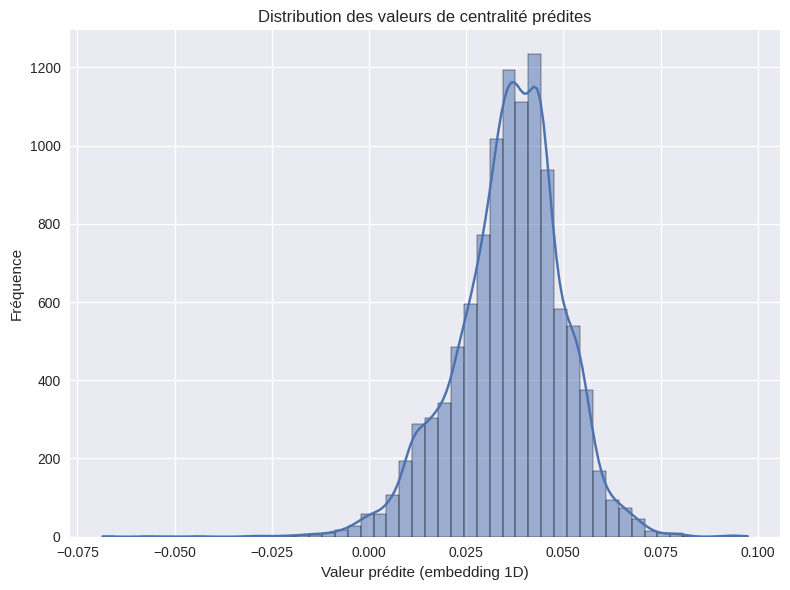

In [28]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

# ✅ Recharger les 6 features utilisées à l'entraînement
data_pyg.x = torch.tensor(
    merged[["gender", "region", "smoker_clean", "drinker_clean", "age_z", "completion_z"]].to_numpy(),
    dtype=torch.float32
)

best_model.eval()
X_full = data_pyg.x.clone()

with torch.no_grad():
    embeddings = best_model(data_pyg.x, data_pyg.edge_index).cpu().numpy()

meta = merged[["region", "age_z"]].reset_index(drop=True)

if embeddings.ndim == 1 or embeddings.shape[1] == 1:
    plt.figure(figsize=(8, 6))
    sns.histplot(embeddings.squeeze(), bins=50, kde=True)
    plt.title("Distribution des valeurs de centralité prédites")
    plt.xlabel("Valeur prédite (embedding 1D)")
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()
else:
    max_points = 5000
    if embeddings.shape[0] > max_points:
        idx = np.random.choice(embeddings.shape[0], max_points, replace=False)
        emb_sample = embeddings[idx]
        meta_sample = meta.iloc[idx].reset_index(drop=True)
    else:
        emb_sample = embeddings
        meta_sample = meta

    tsne_emb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb_sample)
    umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(emb_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.scatterplot(x=tsne_emb[:, 0], y=tsne_emb[:, 1],
                    hue=meta_sample["region"], s=10, ax=axes[0], legend=False)
    axes[0].set_title("t-SNE des embeddings (colorés par région)")
    sns.scatterplot(x=umap_emb[:, 0], y=umap_emb[:, 1],
                    hue=meta_sample["age_z"], s=10, ax=axes[1], legend=False)
    axes[1].set_title("UMAP des embeddings (colorés par âge)")
    plt.tight_layout()
    plt.show()


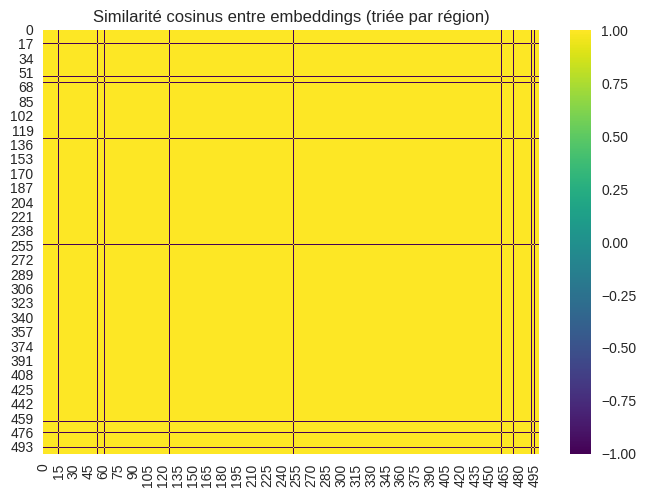

,region,intra,inter
3,8,1.000000,0.959551
2,6,1.000000,0.959732
6,2,1.000000,0.962733
7,7,1.000000,0.961538
4,9,1.000000,0.961373
5,4,1.000000,0.961620
8,3,1.000000,0.963636
1,5,0.924556,0.927198
0,1,0.904819,0.922909
9,10,0.738997,0.840244


In [29]:

# Similarité cosinus + heatmap
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sample_idx = np.random.choice(len(embeddings), size=min(500, len(embeddings)), replace=False)
emb_sample = embeddings[sample_idx]
meta_sample = merged.iloc[sample_idx][["region", "age_z"]].copy()

sim_matrix = cosine_similarity(emb_sample)

sorted_idx = np.argsort(meta_sample["region"])
sns.heatmap(sim_matrix[sorted_idx][:, sorted_idx], cmap="viridis", cbar=True)
plt.title("Similarité cosinus entre embeddings (triée par région)")
plt.show()

meta_sample["region"] = meta_sample["region"].astype(str)
group_sim = []
for region in meta_sample["region"].unique():
    idx = meta_sample["region"] == region
    intra = float(sim_matrix[np.ix_(idx, idx)].mean())
    inter = float(sim_matrix[np.ix_(idx, ~idx)].mean())
    group_sim.append({"region": region, "intra": intra, "inter": inter})

pd.DataFrame(group_sim).sort_values("intra", ascending=False)


## 4.2 Prédiction de liens — test d’homophilie

In [30]:

from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

best_model.eval()
with torch.no_grad():
    z = best_model(data_pyg.x, data_pyg.edge_index)

pos_edge_index = data_pyg.edge_index

neg_edge_index = negative_sampling(
    pos_edge_index,
    num_nodes=data_pyg.num_nodes,
    num_neg_samples=pos_edge_index.size(1),
)

def link_logits(z, edge_index):
    return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

with torch.no_grad():
    pos_score = torch.sigmoid(link_logits(z, pos_edge_index)).cpu().numpy()
    neg_score = torch.sigmoid(link_logits(z, neg_edge_index)).cpu().numpy()

y_true = np.concatenate([np.ones_like(pos_score), np.zeros_like(neg_score)])
y_pred = np.concatenate([pos_score, neg_score])
auc = roc_auc_score(y_true, y_pred)
print(f"AUC (homophilie des liens) : {auc:.4f}")


AUC (homophilie des liens) : 0.3745


## 4.3 Détection de communautés : Louvain vs Embeddings

In [31]:

import networkx as nx
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

try:
    import community as community_louvain
except Exception as e:
    community_louvain = None
    print("community-louvain non disponible, installez 'python-louvain' pour activer cette cellule.")

edges = data_pyg.edge_index.cpu().numpy()
G_tmp = nx.Graph()
G_tmp.add_edges_from(edges.T)

if community_louvain is not None:
    louvain_partition = community_louvain.best_partition(G_tmp)
    louvain_labels = np.array(list(louvain_partition.values()))

    with torch.no_grad():
        embeddings = best_model(data_pyg.x, data_pyg.edge_index).detach().cpu().numpy()
    k = len(np.unique(louvain_labels))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(embeddings)

    nmi = normalized_mutual_info_score(louvain_labels, kmeans_labels)
    print(f"NMI entre Louvain et KMeans sur embeddings : {nmi:.3f}")
else:
    print("NMI non calculé (community-louvain absent).")


NMI entre Louvain et KMeans sur embeddings : 0.007
